In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('../data/processed_data.csv')

In [3]:
df.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,gender_Male,gender_Other,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,0,85.0,8.0,1.0,6,2,1,8,56.2,0,0,1
1,20,6.9,2.8,2.3,0,97.3,4.6,2.0,6,0,1,8,100.0,0,0,0
2,21,1.4,3.1,1.3,0,94.8,8.0,0.0,1,0,0,1,34.3,1,0,0
3,23,1.0,3.9,1.0,0,71.0,9.2,0.0,4,2,2,1,26.8,0,0,1
4,19,5.0,4.4,0.5,0,90.9,4.9,1.0,3,2,2,1,66.4,0,0,0


#### Classify Dependent and Independent Features

In [10]:
X = df.drop('exam_score',axis=1)
y = df['exam_score']

In [8]:
X

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,gender_Male,gender_Other,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,0,85.0,8.0,1.0,6,2,1,8,0,0,1
1,20,6.9,2.8,2.3,0,97.3,4.6,2.0,6,0,1,8,0,0,0
2,21,1.4,3.1,1.3,0,94.8,8.0,0.0,1,0,0,1,1,0,0
3,23,1.0,3.9,1.0,0,71.0,9.2,0.0,4,2,2,1,0,0,1
4,19,5.0,4.4,0.5,0,90.9,4.9,1.0,3,2,2,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,2.6,0.5,1.6,0,77.0,7.5,1.0,2,0,2,6,0,0,1
996,17,2.9,1.0,2.4,1,86.0,6.8,0.0,1,0,1,6,0,0,1
997,20,3.0,2.6,1.3,0,61.9,6.5,2.0,5,1,2,9,1,0,1
998,24,5.4,4.1,1.1,1,100.0,7.6,1.0,0,1,1,1,1,0,0


In [11]:
y

0       56.2
1      100.0
2       34.3
3       26.8
4       66.4
       ...  
995     76.1
996     65.9
997     64.4
998     69.7
999     74.9
Name: exam_score, Length: 1000, dtype: float64

In [30]:
y.describe()

count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [14]:
X_train.shape

(750, 15)

In [15]:
X_test.shape

(250, 15)

#### Feature Selection based on correlaltion

In [17]:
X_train.corr()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,gender_Male,gender_Other,extracurricular_participation_Yes
age,1.000000,0.031392,-0.022027,-0.025213,-0.050296,-0.013640,0.024497,-0.003832,0.016798,0.035856,-0.008970,-0.064901,0.014370,0.020942,-0.007625
study_hours_per_day,0.031392,1.000000,0.005128,-0.001613,-0.030381,0.026707,-0.044104,0.046409,-0.017529,0.002155,0.008288,0.009546,-0.029471,0.016462,-0.033101
social_media_hours,-0.022027,0.005128,1.000000,0.030702,0.017274,0.004174,0.002555,0.013997,-0.022352,-0.038988,0.021065,0.019645,-0.015142,0.028735,-0.036589
netflix_hours,-0.025213,-0.001613,0.030702,1.000000,-0.003737,0.016638,-0.014882,-0.016948,0.000110,0.001498,0.057604,-0.025998,-0.035774,0.019487,-0.012234
part_time_job,-0.050296,-0.030381,0.017274,-0.003737,1.000000,-0.055064,-0.028818,0.032856,-0.011917,-0.011929,0.016657,-0.012514,0.030166,-0.000637,-0.036077
attendance_percentage,-0.013640,0.026707,0.004174,0.016638,-0.055064,1.000000,0.003619,-0.026031,-0.013598,-0.061548,-0.059887,0.029582,-0.023907,-0.033690,-0.003409
sleep_hours,0.024497,-0.044104,0.002555,-0.014882,-0.028818,0.003619,1.000000,-0.054733,0.041941,0.010885,-0.004053,0.041645,-0.009210,0.056153,0.047713
diet_quality,-0.003832,0.046409,0.013997,-0.016948,0.032856,-0.026031,-0.054733,1.000000,-0.004112,-0.019004,0.031486,-0.013180,0.023676,-0.023194,-0.025258
exercise_frequency,0.016798,-0.017529,-0.022352,0.000110,-0.011917,-0.013598,0.041941,-0.004112,1.000000,-0.056571,-0.027440,-0.029557,0.038699,0.004600,0.006144
parental_education_level,0.035856,0.002155,-0.038988,0.001498,-0.011929,-0.061548,0.010885,-0.019004,-0.056571,1.000000,0.038500,-0.049978,0.017459,-0.067991,0.011817


<Axes: >

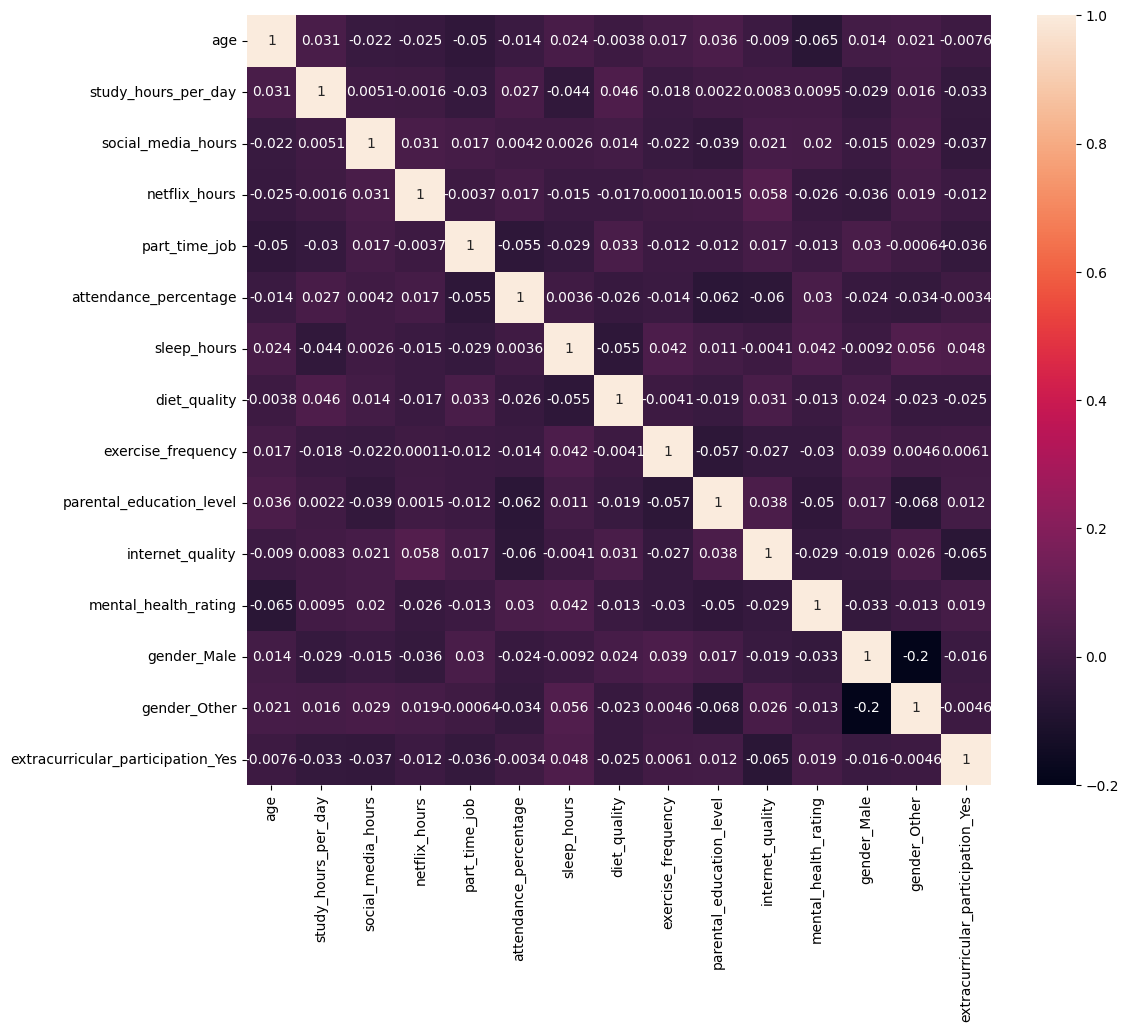

In [18]:
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [19]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [20]:
corr_features=correlation(X_train,0.85)

In [21]:
corr_features

set()

#### As here we get empty set, We do not need to remove any features from the dataset

## Standardization

In [22]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Text(0.5, 1.0, 'X_train After Scaling')

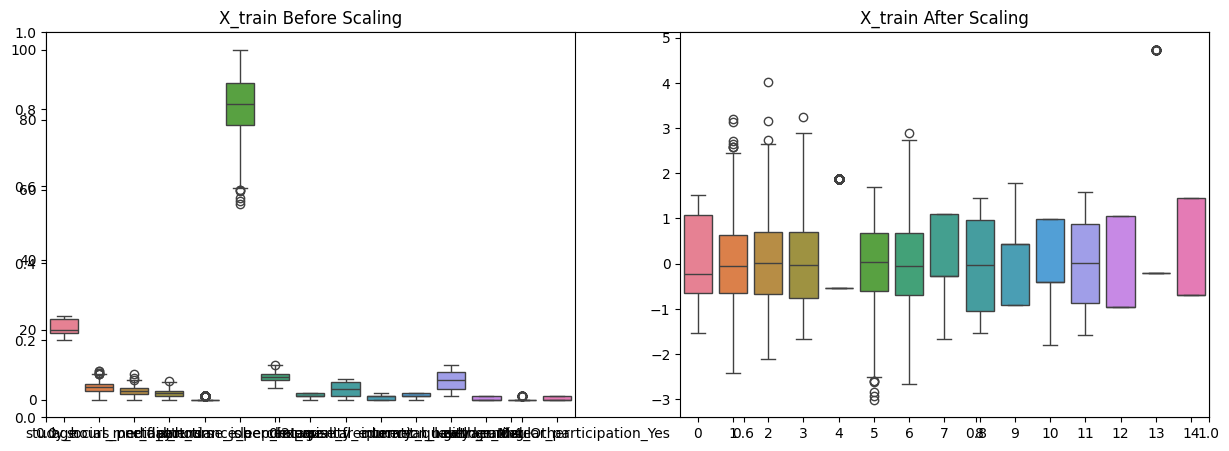

In [23]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

#### See how much scaling has affected the Training Data

Mean absolute error 4.247744559754258
R2 Score 0.8943322300576574


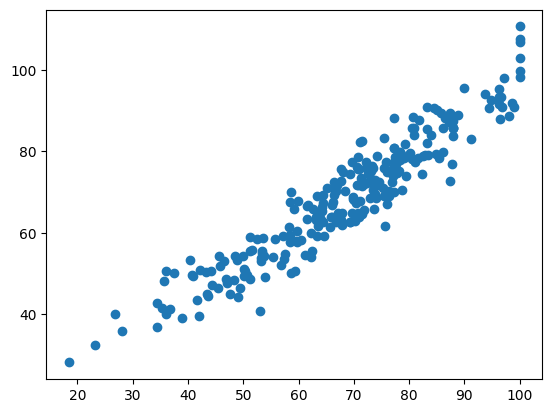

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

#### This means from the Linear Regression Model we got an accuraccy of almost 89%

In [26]:
import pickle

pickle.dump(linreg,open("../models/linreg.pkl",'wb'))
pickle.dump(scaler,open("../models/scaler.pkl",'wb'))

#### Now our model is ready to be used in FastAPI server

In [29]:
df['parental_education_level'].unique()

array([2, 0, 1])